<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>AULA PRÁTICA 6 (Parte II): Segmentação de imagens com RNC</center>**

**Objetivo:** Apresentar o conceito de segmentação de imagens e implementar um modelo `U-Net modificada` usando TensorFlow.

**Exemplo prático:** Segmentação de imagens de gatos e cachorros do dataset `Oxford-IIIT Pets`.

**1) Preparação do Ambiente**

In [1]:
!pip install git+https://github.com/tensorflow/examples.git
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output
import matplotlib.pyplot as plt

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-d3v5qmt4
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-d3v5qmt4
  Resolved https://github.com/tensorflow/examples.git to commit c82672b5a69916f22b0dd380481e000142c746d5
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1755771098.1142655575095463436003189777410900689228873025237-py3-none-any.whl size=301661 sha256=12192a229a89d6b0c488c7937fd970ad8b8277b9483807b6f5b271afcb6c9f83
  Stored in directory: /tmp/pip-ephem-wheel-cache-2o6a2c_n/wheels/ab/17/30/d16d07e2c95286770a9ddcd6f41629ea92b998858c5ee235aa
Successfully built tensorflow-examples


**2) Carregar o Dataset Oxford-IIIT Pets**

In [2]:
dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.7IYURD_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.7IYURD_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


**3) Pré-processamento**

In [3]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
    return input_image, input_mask

def load_image(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(
        datapoint['segmentation_mask'],
        (128, 128),
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask


**4) Divisão do Dataset**

In [4]:
TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)


**5) Data Augmentation**

In [5]:
class Augment(tf.keras.layers.Layer):
    def __init__(self, seed=42):
        super().__init__()
        self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
        self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)
        return inputs, labels

**6) Criar Pipeline de Entrada**

In [6]:
train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_batches = test_images.batch(BATCH_SIZE)


**7) Visualização**

In [7]:
def display(display_list):
    plt.figure(figsize=(15, 15))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()


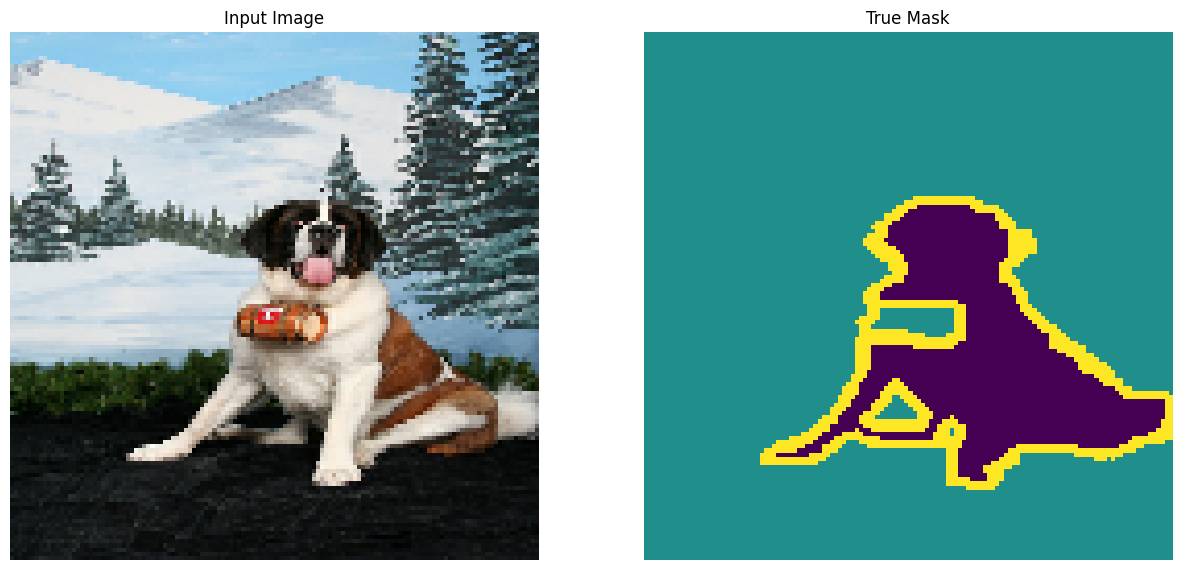

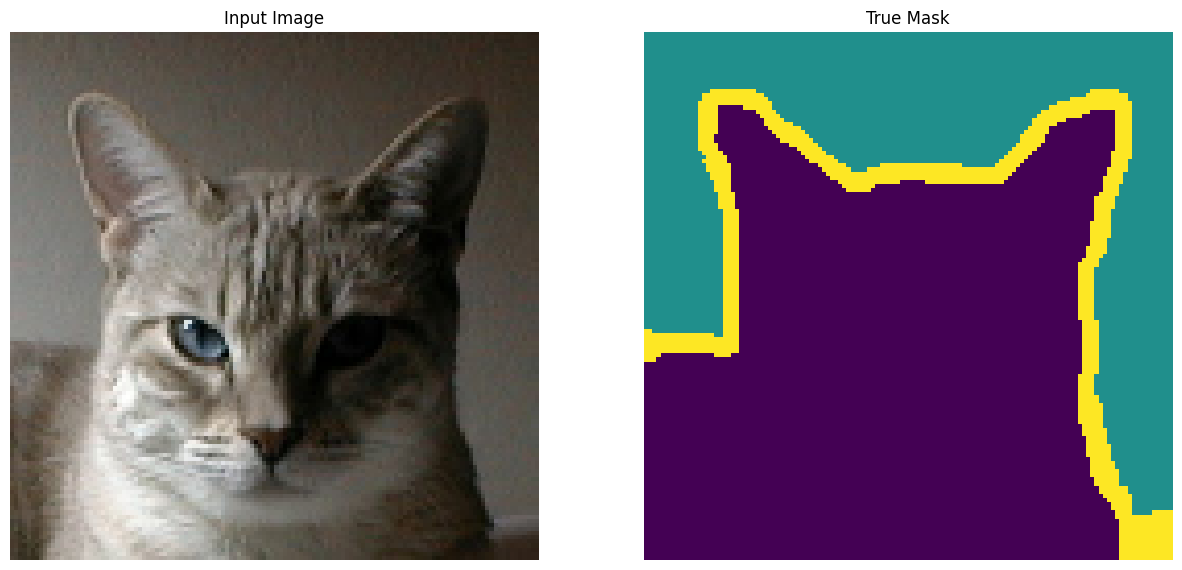

In [8]:
for images, masks in train_batches.take(2):
  sample_image, sample_mask = images[0], masks[0]
  display([sample_image, sample_mask])

**8) Definição do Modelo U-Net**

**8.1) Encoder**

In [9]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]

base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**8.2) Decoder**

In [10]:
up_stack = [
    pix2pix.upsample(512, 3), # 4x4 -> 8x8
    pix2pix.upsample(256, 3), # 8x8 -> 16x16
    pix2pix.upsample(128, 3), # 16x16 -> 32x32
    pix2pix.upsample(64, 3),  # 32x32 -> 64x64
]


**8.3) Função para construir a U-Net**

In [11]:
def unet_model(output_channels:int):
    inputs = tf.keras.layers.Input(shape=[128,128,3])
    skips = down_stack(inputs)
    x = skips[-1]        # saída mais profunda (4x4)
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip]) # skip connection
    last = tf.keras.layers.Conv2DTranspose(filters=output_channels, kernel_size=3, strides=2, padding='same')
    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)


**9) Compilar o Modelo**

In [12]:
OUTPUT_CLASSES = 3
model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


**10) Callbacks e Treinamento**

In [13]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(dataset=None, num=1):
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask, create_mask(model.predict(sample_image[tf.newaxis, ...]))])

BATCH_SIZE = 64
N samples = 3669

Amostras por epoca= 3669/64 = 57
57/5=11


Ou seja, no treinamento, a validação não vai rodar nos 57 steps (todo o conjunto de teste), mas apenas em 11 steps por época.
Isso é uma escolha para economizar tempo de treino:
 → validação mais rápida, mas menos detalhada.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


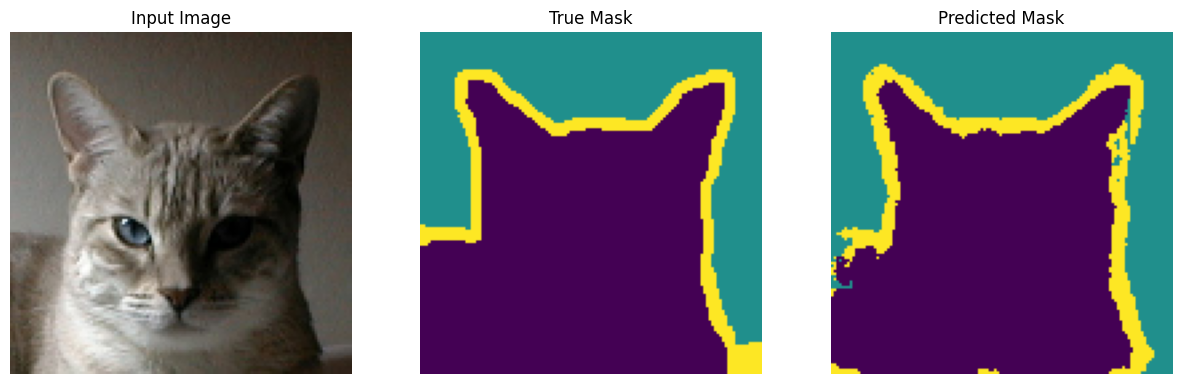


Sample Prediction after epoch 10

57/57 ━━━━━━━━━━━━━━━━━━━━ 442s 8s/step - accuracy: 0.9115 - loss: 0.2224 - val_accuracy: 0.8979 - val_loss: 0.2708


In [14]:
class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)
        show_predictions()
        print(f'\nSample Prediction after epoch {epoch+1}\n')

EPOCHS = 10
VALIDATION_STEPS = info.splits['test'].num_examples // BATCH_SIZE // 5

model_history = model.fit(train_batches,
                          epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_batches,
                          callbacks=[DisplayCallback()])

**11) Avaliação e Resultados**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


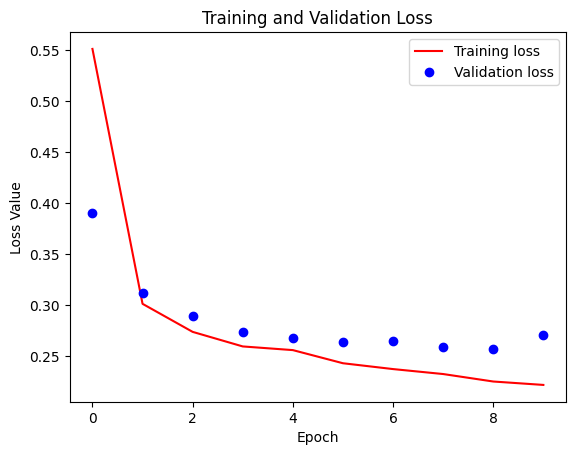

In [20]:
from google.colab import drive
drive.mount('/content/drive')

loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(range(len(loss)), loss, 'r', label='Training loss')
plt.plot(range(len(val_loss)), val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()

# salva no Drive
plt.savefig("/content/drive/MyDrive/ELT578/SEMANA_3/training_validation_loss.png",
            dpi=300, bbox_inches='tight')

plt.show()


**12) Predição**

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


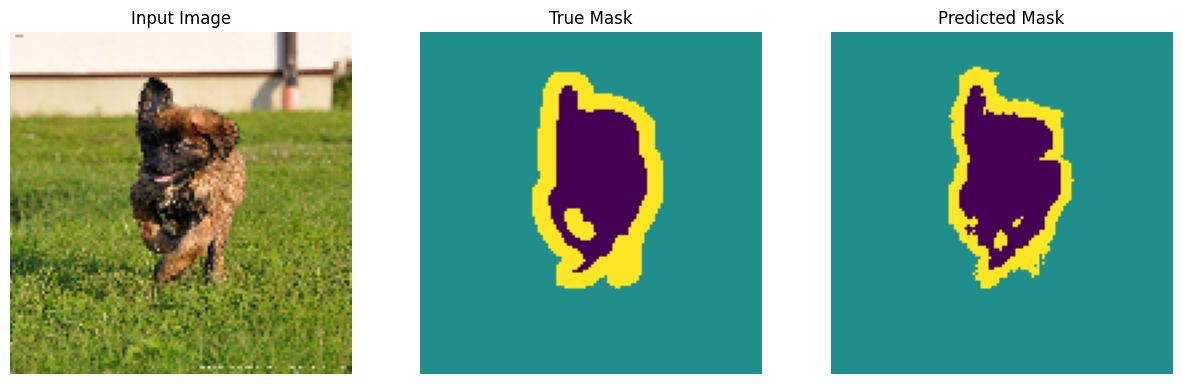

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


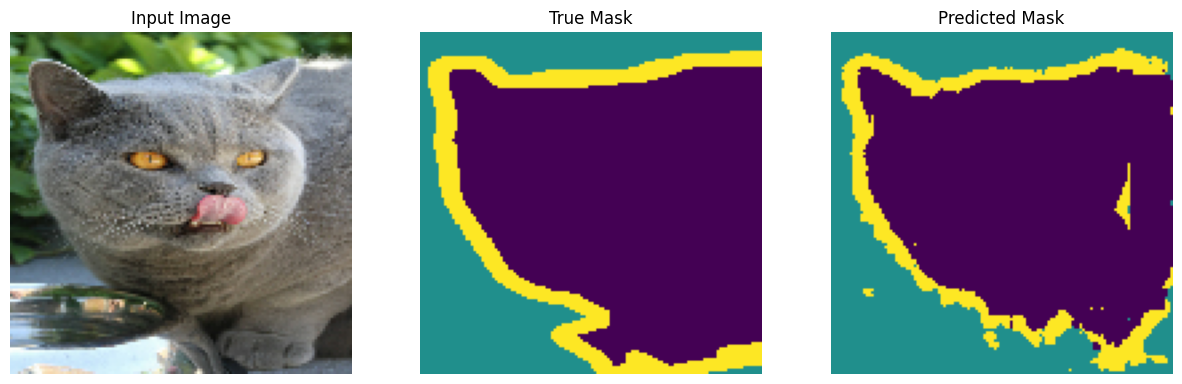

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


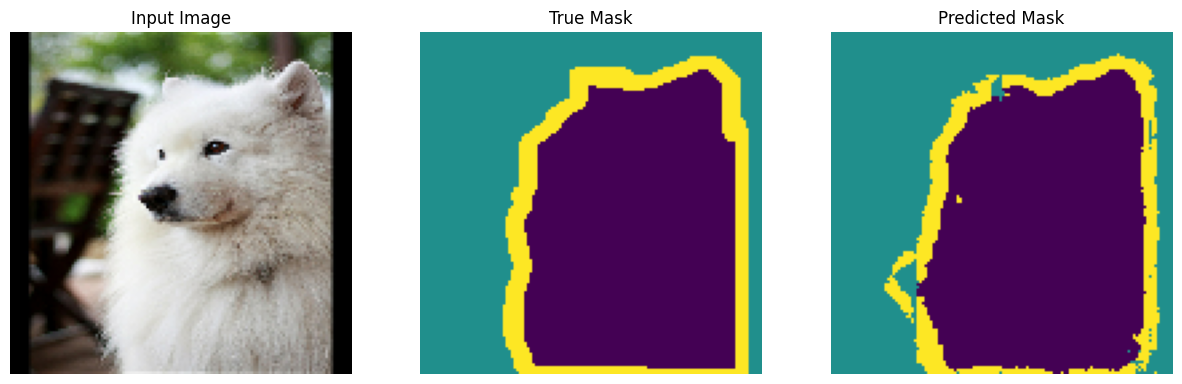

In [16]:
show_predictions(test_batches, 3)


**Conclusão**

*   A segmentação pixel a pixel é poderosa para problemas de visão computacional.
*   A U-Net com encoder pré-treinado acelera o aprendizado.
*   Esse mesmo pipeline pode ser adaptado para segmentação médica, autônoma, agrícola etc.

**DESAFIO**

*   Interpretar os resultados de treinamento e validação "training and validation loss"

